In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset

path_1 ="C:/Users/HAROON TRADERS/Documents/DS Stuff/KNN - Cyber/data/financial_impact.csv"
path_2 ="C:/Users/HAROON TRADERS/Documents/DS Stuff/KNN - Cyber/data/incidents_master.csv"
path_3 ="C:/Users/HAROON TRADERS/Documents/DS Stuff/KNN - Cyber/data/market_impact.csv"
data_finan = pd.read_csv(path_1)
data_incident = pd.read_csv(path_2)
data_market = pd.read_csv(path_3)

In [27]:
df = pd.merge(data_finan, data_incident, on='incident_id')
df_final = pd.merge(df, data_market, on='incident_id', how = "outer")
df_final

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2021-0101-001,4967279.14,disclosed,9698485.95,5717211.61,company statement,2488838.05,1127543.48,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-0109-001,2066546.90,estimated,NaN,NaN,NaN,1829572.96,600867.65,NaN,1678410.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-0111-001,1600000.00,calculated,NaN,NaN,NaN,584549.71,406861.16,NaN,564566.39,...,1.00000,False,3.861498e+09,2.3269,0.020707,0.031208,49.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0117-001,2827335.54,calculated,2193976.56,1738883.24,blockchain analysis,2387941.53,474124.37,NaN,NaN,...,0.85785,False,1.378666e+09,2.7503,0.030143,0.034480,325.0,Elevated options activity detected 10 days bef...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-0120-001,78022211.29,disclosed,1397414.98,804045.32,blockchain analysis,44863921.70,21170665.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,2025-1226-001,5119285.75,disclosed,NaN,NaN,NaN,3553590.95,1633789.43,NaN,2543920.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
803,2025-1226-002,4760046.30,calculated,108866.54,NaN,NaN,4843245.47,362343.15,302251.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
804,2025-1227-001,43536609.85,estimated,NaN,NaN,NaN,42245003.39,8910659.60,NaN,47202487.06,...,1.00000,False,3.164782e+10,2.5244,0.010872,0.020354,144.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
805,2025-1231-001,9944830.62,disclosed,93173.95,NaN,NaN,10655366.28,896669.47,NaN,7135514.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Finance Data", data_finan.shape)
print("Incident Data", data_incident.shape)
print("Market Data", data_market.shape)

print("Merge Data", df_final.shape)

Finance Data (778, 19)
Incident Data (850, 32)
Market Data (358, 31)
Merge Data (807, 80)


In [48]:
num_columns

,direct_loss_usd,ransom_demanded_usd,ransom_paid_usd,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_lower_bound,total_loss_upper_bound,...,car_0_to_90,t_statistic_1d,p_value_1d,t_statistic_30d,p_value_30d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery
0,4967279.14,9698485.95,5717211.61,2488838.05,1127543.48,NaN,NaN,1.430087e+07,11751536.23,2.311578e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2066546.90,NaN,NaN,1829572.96,600867.65,NaN,1678410.68,4.496988e+06,3072502.06,5.173250e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1600000.00,NaN,NaN,584549.71,406861.16,NaN,564566.39,2.591411e+06,2032977.68,3.348118e+06,...,0.003527,-0.6066,1.00000,-0.6717,1.00000,3.861498e+09,2.3269,0.020707,0.031208,49.0
3,2827335.54,2193976.56,1738883.24,2387941.53,474124.37,NaN,NaN,7.428285e+06,5571388.50,1.067968e+07,...,-0.034650,-2.4595,0.77025,-2.2843,0.85785,1.378666e+09,2.7503,0.030143,0.034480,325.0
4,78022211.29,1397414.98,804045.32,44863921.70,21170665.28,NaN,NaN,1.448608e+08,99760681.33,1.878221e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,5119285.75,NaN,NaN,3553590.95,1633789.43,NaN,2543920.34,1.030667e+07,7308778.60,1.224071e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
803,4760046.30,108866.54,NaN,4843245.47,362343.15,302251.9,NaN,1.026789e+07,7135384.53,1.740406e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
804,43536609.85,NaN,NaN,42245003.39,8910659.60,NaN,47202487.06,9.469227e+07,79848642.88,1.571700e+08,...,-0.033981,-3.1237,0.43815,-1.0117,1.00000,3.164782e+10,2.5244,0.010872,0.020354,144.0
805,9944830.62,93173.95,NaN,10655366.28,896669.47,NaN,7135514.59,2.149687e+07,12955041.82,2.805927e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


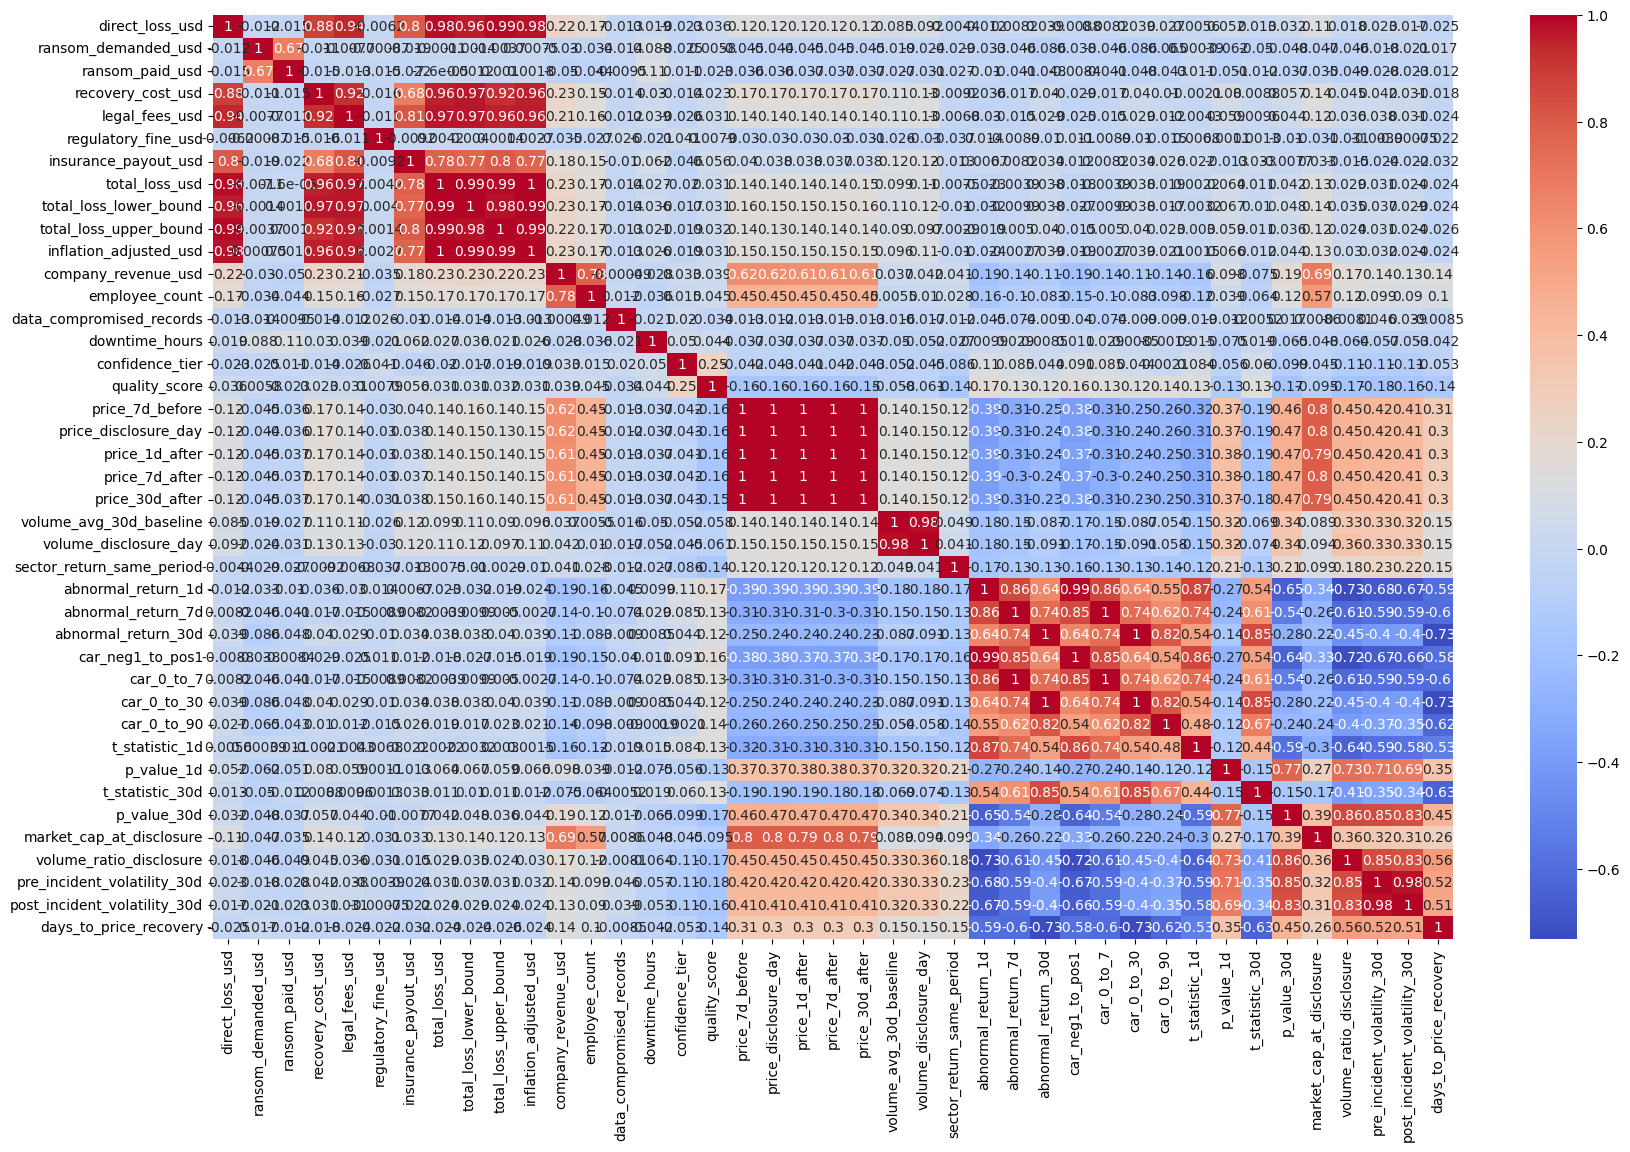

In [49]:
plt.figure(figsize=(20, 12))


import seaborn as sns
num_columns = df_final.select_dtypes(include=['number']).fillna(0)
cat_columns = df_final.select_dtypes(include=["object"])

corr_matrix = num_columns.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm') # 2. Plot Heatmap

plt.show()

In [52]:
cat_columns

,incident_id,direct_loss_method,ransom_source,total_loss_method,cpi_index_used,notes_x,created_at_x,updated_at_x,company_name,country_hq,...,review_flag,notes_y,created_at_y,updated_at_y,stock_ticker_y,sector_index,earnings_announcement_within_7d,notes,created_at,updated_at
0,2021-0101-001,disclosed,company statement,estimated,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,DrillWell Energy Ltda.,BR,...,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-0109-001,estimated,NaN,calculated,CPI-U 2021 (270.97),Cyber insurance policy sublimit of $21.5M appl...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,Pittsburgh Products Corp.,US,...,NaN,Incident scope expanded during investigation; ...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-0111-001,calculated,NaN,disclosed,CPI-U 2021 (270.97),Recovery includes infrastructure rebuild; comp...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,Chandra Electric Group Inc.,US,...,NaN,Multiple subsidiaries affected across 7 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,CHAN,S&P 500 Utilities,False,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0117-001,calculated,blockchain analysis,disclosed,CPI-U 2021 (270.97),Insurance claim partially denied; payout refle...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,TrustCommerce Financial Co. Ltd.,JP,...,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,TRUS.T,S&P 500 Financials,False,Elevated options activity detected 10 days bef...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-0120-001,disclosed,blockchain analysis,estimated,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,Polaris Drill Mining Inc.,CA,...,NaN,Initially reported as IT maintenance outage; l...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,2025-1226-001,disclosed,NaN,disclosed,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,CastComponent Industrial Group SA,FR,...,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN
803,2025-1226-002,calculated,NaN,disclosed,CPI-U 2025 (321.5),Direct costs confirmed via SEC 8-K filing on 2...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,Delta Precision Works Holdings Inc.,MX,...,NaN,Insider threat component confirmed alongside e...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN
804,2025-1227-001,estimated,NaN,estimated,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,Nakamura Retail Co.,US,...,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,NAKA,S&P 500 Consumer Discretionary,False,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
805,2025-1231-001,disclosed,NaN,calculated,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,Lambert MedTech Co.,US,...,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN
